# MobileNetV2 - Road Damage Classification (RDD2020)
**Member:** IT22063564 · SE4050 Deep Learning 2026

Classifies road-damage crops into **D00** (longitudinal crack), **D10** (transverse crack), **D20** (alligator crack) and **D40** (pothole) with an ImageNet-pretrained MobileNetV2, using two-phase transfer learning.

All logic lives in `src/IT22063564/` - this notebook only runs it and shows the results:

| Step | Script |
|---|---|
| Build crops + image-level train/val/test split | `prepare_data.py` |
| Train (phase 1 head only, phase 2 fine-tune) | `train.py` |
| Final test evaluation | `evaluate.py` |

Settings: `src/IT22063564/configs/common.yaml` (shared: seed, split, image size) and `configs/mobilenetv2.yaml` (model).

**Runtime:** use a GPU. In Colab: *Runtime → Change runtime type → T4 GPU*.

## 1. Environment setup
On Colab this clones the repo (branch `feature/IT22063564`) and mounts Google Drive. Locally it just moves to the repo root.

In [1]:
import os, sys

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/DhanaM24/SE4050-Deep-Learning-Assignment.git"
BRANCH = "feature/IT22063564"
DRIVE_DIR = "/content/drive/MyDrive/data"      # Drive folder holding the zip
ZIP_NAME = "processed.zip"                    # crops built by prepare_data.py

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive")
    if not os.path.exists("/content/SE4050-Deep-Learning-Assignment"):
        !git clone -b {BRANCH} {REPO_URL} /content/SE4050-Deep-Learning-Assignment
    os.chdir("/content/SE4050-Deep-Learning-Assignment")
    !pip install -q -r requirements.txt
else:
    # running locally from notebooks/IT22063564/
    os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..", "..")))

print("Working directory:", os.getcwd())

Working directory: C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment


In [2]:
import tensorflow as tf
print("TensorFlow", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU") or "none - training will be very slow")

TensorFlow 2.21.0


GPU: none - training will be very slow


## 2. Data
Two options:
* **A (recommended on Colab):** upload the already-built crops zip (~100 MB) to Drive (`MyDrive/data/processed.zip`) - it is unzipped automatically.
* **B:** extract `data/train.tar.gz` into `data/raw/` and run `prepare_data.py` to rebuild the crops.

The split is done **per source image** (70/15/15, seed 42) so no photo contributes crops to two splits. The RDD2020 `test1`/`test2` sets have no labels, so the test split comes from the training archive.

In [3]:
from pathlib import Path

if not Path("data/processed/crops/train").exists():
    zip_path = f"{DRIVE_DIR}/{ZIP_NAME}" if IN_COLAB else "data/IT22063564_processed.zip"
    if Path(zip_path).exists():                     # option A
        !unzip -q -o "{zip_path}" -d data/_unzipped
        # accept zips whose top folder is "processed/", "crops/" or the split folders themselves
        crops = next(Path("data/_unzipped").rglob("train")).parent
        Path("data/processed").mkdir(parents=True, exist_ok=True)
        if crops.name == "crops":
            !cp -r "{crops.parent}/." data/processed/
        else:
            !mkdir -p data/processed/crops && cp -r "{crops}/." data/processed/crops/
        !rm -rf data/_unzipped
    else:                                           # option B
        !"{sys.executable}" src/IT22063564/prepare_data.py

print({s: sum(1 for _ in Path(f"data/processed/crops/{s}").rglob("*.jpg")) for s in ("train", "val", "test")})

label   D00  D10   D20   D40
split                       
test    354   52   321   452
train  1768  257  1530  2337
val     396   62   331   474 
 Saved 8334 crops from 4234 images to C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\data\processed
Dropped: {'too_small': 242, 'label_D44': 1062, 'label_D01': 179, 'label_D11': 45, 'label_D50': 28, 'label_D43': 57, 'label_D0w0': 1}


{'train': 5892, 'val': 1263, 'test': 1179}


,D00,D10,D20,D40
train,1768,257,1530,2337
val,396,62,331,474
test,354,52,321,452


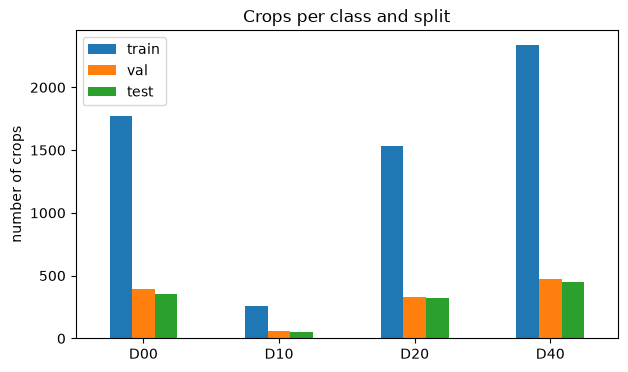

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

classes = ["D00", "D10", "D20", "D40"]
counts = pd.DataFrame({c: [len(list(Path(f"data/processed/crops/{s}/{c}").glob("*.jpg"))) for s in ("train", "val", "test")]
                       for c in classes}, index=["train", "val", "test"])
display(counts)

counts.T.plot(kind="bar", figsize=(7, 4), title="Crops per class and split")
plt.ylabel("number of crops"); plt.xticks(rotation=0); plt.show()

## 3. Train
Phase 1: backbone frozen, head trained (lr 1e-3, ≤10 epochs). Phase 2: backbone layers 100+ unfrozen, BatchNorm frozen (lr 1e-5, ≤20 epochs). Early stopping on validation loss; the best checkpoint is saved to `results/models/mobilenetv2.keras`. Only train + val data are used here.

In [5]:
!"{sys.executable}" src/IT22063564/train.py

Found 5892 files belonging to 4 classes.
Found 1263 files belonging to 4 classes.
Class weights: {0: 0.8331447963800905, 1: 5.7315175097276265, 2: 0.9627450980392157, 3: 0.6302952503209243}

      0/9406464 ==================== 0s 0s/step
  24576/9406464 ==================== 35s 4us/step
  49152/9406464 ==================== 43s 5us/step
  81920/9406464 ==================== 46s 5us/step
 114688/9406464 ==================== 37s 4us/step
 147456/9406464 ==================== 32s 4us/step
 180224/9406464 ==================== 29s 3us/step
 212992/9406464 ==================== 27s 3us/step
 262144/9406464 ==================== 24s 3us/step
 311296/9406464 ==================== 22s 2us/step
 401408/9406464 ==================== 18s 2us/step
 475136/9406464 ==================== 16s 2us/step
 606208/9406464 ==================== 13s 2us/step
 712704/9406464 ==================== 12s 1us/step
 892928/9406464 ==================== 10s 1us/step
1064960/9406464 ==================== 8s 1us/step 
1343488/940

I0000 00:00:1790634758.425273   45004 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790634771.224698   45004 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790634775.223331   45004 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
C:\Users\ASUS\Desktop\SLIIT\Year 4\Semester 2\Deep Learning\Assignment\SE4050-Deep-Learning-Assignment\venv\Lib

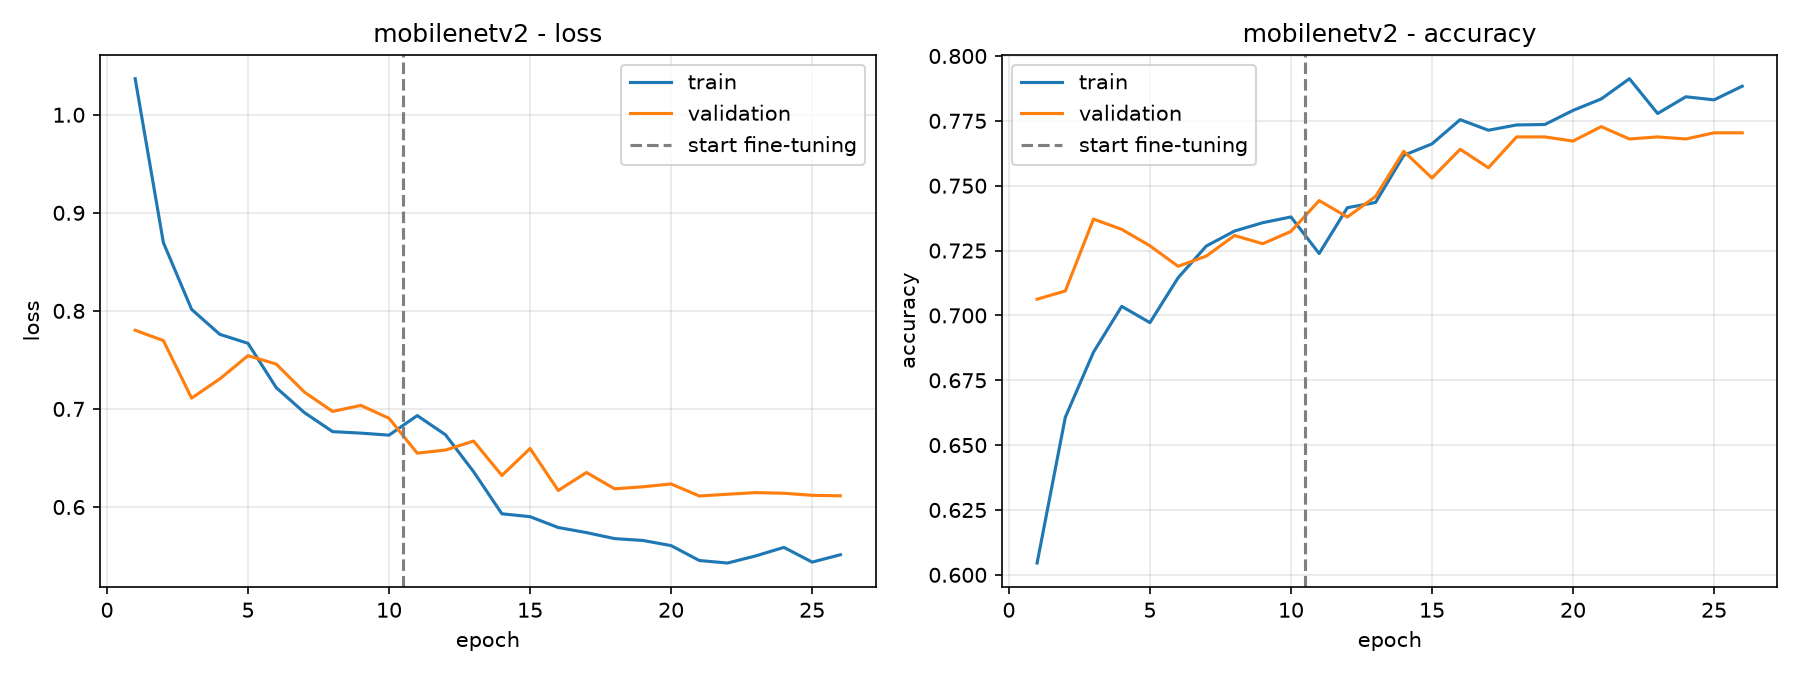

,accuracy,auc,loss,val_accuracy,val_auc,val_loss,learning_rate,epoch,phase,epoch_seconds
0,0.6045,0.8208,1.0368,0.7063,0.8914,0.7802,0.0010,1,phase1,99.1297
1,0.6607,0.8715,0.8696,0.7094,0.9024,0.7697,0.0010,2,phase1,93.7746
2,0.6858,0.8888,0.8016,0.7371,0.9066,0.7111,0.0010,3,phase1,94.0491
3,0.7035,0.8976,0.7761,0.7332,0.9094,0.7306,0.0010,4,phase1,95.2119
4,0.6972,0.8990,0.7669,0.7268,0.9035,0.7543,0.0010,5,phase1,95.2093
5,0.7145,0.9088,0.7218,0.7189,0.9090,0.7458,0.0003,6,phase1,95.0671
6,0.7267,0.9157,0.6963,0.7229,0.9130,0.7172,0.0003,7,phase1,94.9721
7,0.7325,0.9205,0.6769,0.7308,0.9139,0.6975,0.0001,8,phase1,94.2641
8,0.7357,0.9202,0.6754,0.7276,0.9129,0.7036,0.0001,9,phase1,94.6356
9,0.7379,0.9206,0.6733,0.7324,0.9147,0.6905,0.0001,10,phase1,94.5212


In [6]:
from IPython.display import Image, display
display(Image("results/IT22063564/figures/mobilenetv2_learning_curves.png"))
pd.read_csv("results/IT22063564/tables/mobilenetv2_history.csv").round(4)

## 4. Evaluate on the held-out test set
Run this **once**, after all tuning is finished.

In [7]:
!"{sys.executable}" src/IT22063564/evaluate.py

Found 5892 files belonging to 4 classes.
train: accuracy=0.7970, precision_macro=0.7315, recall_macro=0.8139, f1_macro=0.7541, precision_weighted=0.8126, recall_weighted=0.7970, f1_weighted=0.8001, roc_auc_macro_ovr=0.9555
Found 1263 files belonging to 4 classes.
  val: accuracy=0.7728, precision_macro=0.7072, recall_macro=0.7644, f1_macro=0.7231, precision_weighted=0.7871, recall_weighted=0.7728, f1_weighted=0.7751, roc_auc_macro_ovr=0.9291
Found 1179 files belonging to 4 classes.
 test: accuracy=0.7820, precision_macro=0.7195, recall_macro=0.7837, f1_macro=0.7401, precision_weighted=0.7936, recall_weighted=0.7820, f1_weighted=0.7848, roc_auc_macro_ovr=0.9416

       model  test_accuracy  test_precision_macro  test_recall_macro  test_f1_macro  test_roc_auc_macro  train_accuracy  val_accuracy  generalization_gap  params_millions  model_size_mb  latency_ms  train_minutes  epochs_run device
mobilenetv2       0.782019              0.719528           0.783729        0.74007            0.94

I0000 00:00:1790637489.552748   15100 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790637492.533245   15100 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1790637495.146896   15100 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [8]:
import json
metrics = json.load(open("results/IT22063564/tables/mobilenetv2_metrics.json"))
summary = pd.DataFrame({s: {k: v for k, v in metrics[s].items() if k != "confusion_matrix"}
                        for s in ("train", "val", "test")}).T
display(summary.round(4))
display(pd.Series(metrics["efficiency"], name="efficiency"))
display(pd.read_csv("results/IT22063564/tables/mobilenetv2_classification_report.csv", index_col=0).round(4))

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,roc_auc_macro_ovr,n_samples
train,0.7970,0.7315,0.8139,0.7541,0.8126,0.7970,0.8001,0.9555,5892.0
val,0.7728,0.7072,0.7644,0.7231,0.7871,0.7728,0.7751,0.9291,1263.0
test,0.7820,0.7195,0.7837,0.7401,0.7936,0.7820,0.7848,0.9416,1179.0


total_params               2422468
model_size_mb            26.353481
latency_ms_per_image    114.154623
device                         CPU
Name: efficiency, dtype: object

,precision,recall,f1-score,support
D00,0.7898,0.7006,0.7425,354.000
D10,0.4773,0.8077,0.6000,52.000
D20,0.7398,0.7882,0.7632,321.000
D40,0.8713,0.8385,0.8546,452.000
accuracy,0.7820,0.7820,0.7820,0.782
macro avg,0.7195,0.7837,0.7401,1179.000
weighted avg,0.7936,0.7820,0.7848,1179.000


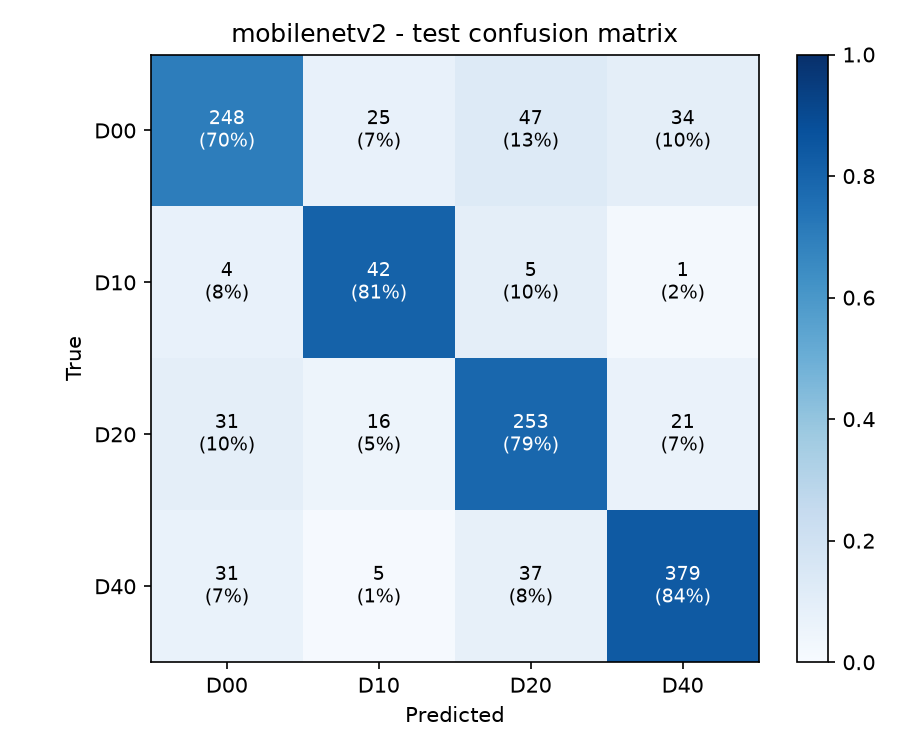

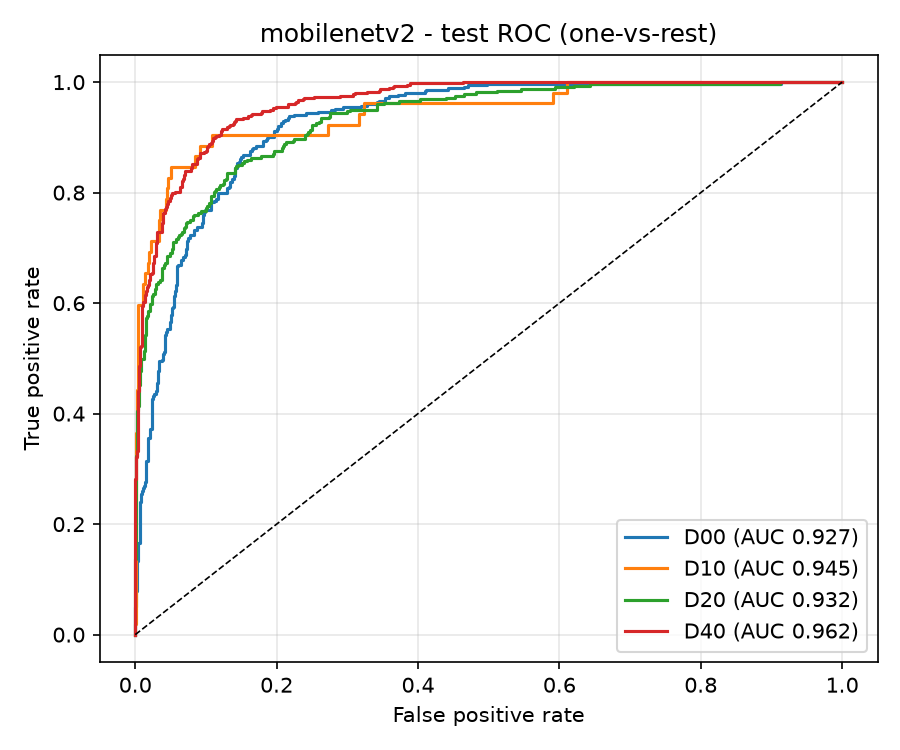

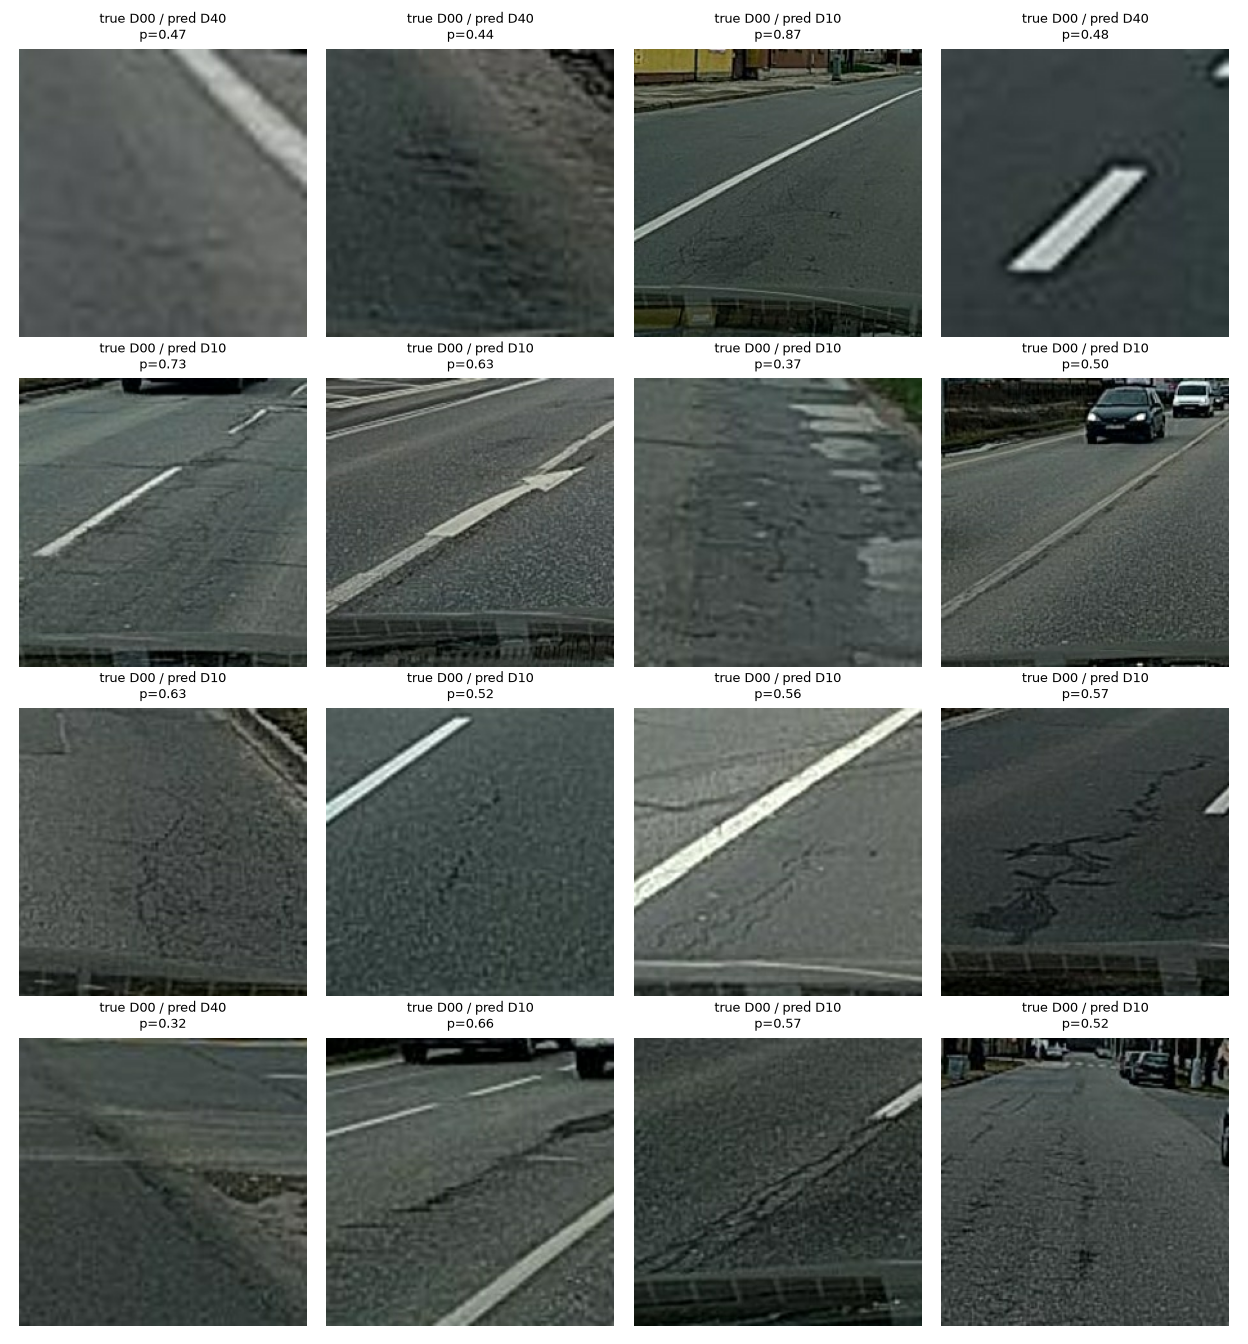

In [9]:
for fig in ("confusion_matrix", "roc_curves", "misclassified"):
    display(Image(f"results/IT22063564/figures/mobilenetv2_{fig}.png"))

## 5. Save results
Colab storage is temporary - copy results to Drive, then commit `results/IT22063564/tables` and `results/IT22063564/figures` to the repo (the `.keras` weights are git-ignored).

In [10]:
if IN_COLAB:
    !mkdir -p "{DRIVE_DIR}/results" && cp -r results/IT22063564/* "{DRIVE_DIR}/results/"
    print("Copied to", DRIVE_DIR + "/results")